# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [13]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [14]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [15]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

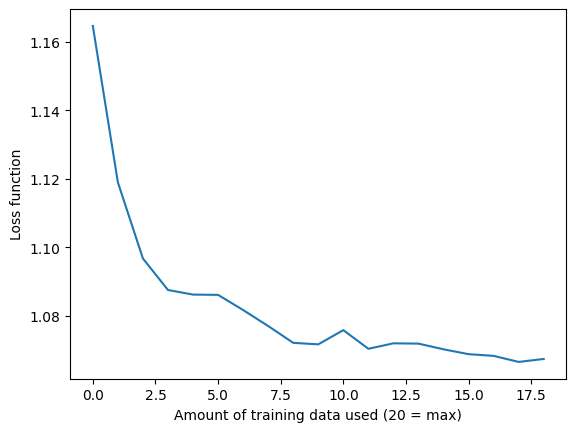

In [16]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [17]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

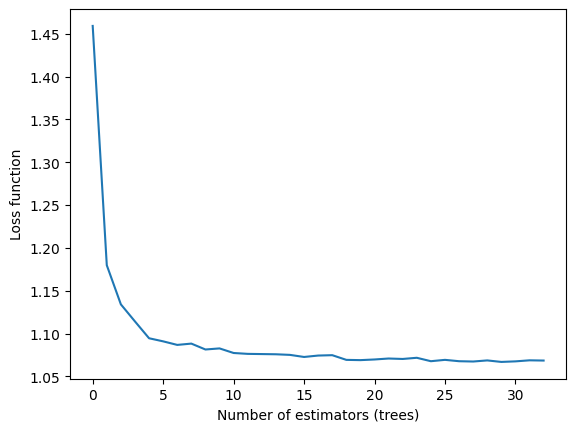

In [18]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

### Graph Reflection – Keep It Simple

I’d keep the cleaner graph—the one that shows performance with fewer distractions. Even if the other graph has more detail, it clutters the message. The simple version still tells the full story: how model performance changes over time or with more data.

As Vonnegut said, “have the guts to cut.” If a chart has extra lines, to much or unnecessarily long labels, or legends that don’t add clarity, they’re just noise.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [5]:
# === STEP 0: CONFIG GENERATOR ===
# Purpose: If dataset_config.csv does not exist, generate it from default list of dataset settings.

import os
import pandas as pd

def generate_default_dataset_config():
    config_path = "dataset_config.csv"
    if os.path.exists(config_path):
        print("[INFO] dataset_config.csv already exists.")
        return

    default_configs = [
        {
            "csv_path": "GlobalRenewEnergyProd_2000_2022/IRENA_RenewableEnergy_Statistics_2000-2022.csv",
            "target_column": "Electricity Generation (GWh)",
            "drop_columns": "[]",
            "plot_title": "IRENA: Electricity Generation"
        },
        {
            "csv_path": "USEnergyGen_2001_2022/organised_Gen.csv",
            "target_column": "GENERATION (Megawatthours)",
            "drop_columns": "[]",
            "plot_title": "US: Electricity Generation"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/01 renewable-share-energy.csv",
            "target_column": "Renewables (% equivalent primary energy)",
            "drop_columns": "[]",
            "plot_title": "Global: Renewable Share Energy"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/02 modern-renewable-energy-consumption.csv",
            "target_column": "Geo Biomass Other - TWh",
            "drop_columns": "[]",
            "plot_title": "Modern Renewable Energy Consumption"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/03 modern-renewable-prod.csv",
            "target_column": "Other renewables including bioenergy (TWh)",
            "drop_columns": "[]",
            "plot_title": "Modern Renewable Production"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/04 share-electricity-renewables.csv",
            "target_column": "Renewables (% electricity)",
            "drop_columns": "[]",
            "plot_title": "Share Electricity Renewables"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/05 hydropower-consumption.csv",
            "target_column": "Electricity from hydro (TWh)",
            "drop_columns": "[]",
            "plot_title": "Hydropower Consumption"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/06 hydro-share-energy.csv",
            "target_column": "Hydro (% equivalent primary energy)",
            "drop_columns": "[]",
            "plot_title": "Hydro Share Energy"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/07 share-electricity-hydro.csv",
            "target_column": "Hydro (% electricity)",
            "drop_columns": "[]",
            "plot_title": "Share of Electricity from Hydro"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/08 wind-generation.csv",
            "target_column": "Electricity from wind (TWh)",
            "drop_columns": "[]",
            "plot_title": "Wind Generation"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/09 cumulative-installed-wind-energy-capacity-gigawatts.csv",
            "target_column": "Wind Capacity",
            "drop_columns": "[]",
            "plot_title": "Cumulative Wind Capacity"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/10 wind-share-energy.csv",
            "target_column": "Wind (% equivalent primary energy)",
            "drop_columns": "[]",
            "plot_title": "Wind Share Energy"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/11 share-electricity-wind.csv",
            "target_column": "Wind (% electricity)",
            "drop_columns": "[]",
            "plot_title": "Share of Electricity from Wind"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/12 solar-energy-consumption.csv",
            "target_column": "Electricity from solar (TWh)",
            "drop_columns": "[]",
            "plot_title": "Solar Energy Consumption"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/13 installed-solar-PV-capacity.csv",
            "target_column": "Solar Capacity",
            "drop_columns": "[]",
            "plot_title": "Installed Solar PV Capacity"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/14 solar-share-energy.csv",
            "target_column": "Solar (% equivalent primary energy)",
            "drop_columns": "[]",
            "plot_title": "Solar Share Energy"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/15 share-electricity-solar.csv",
            "target_column": "Solar (% electricity)",
            "drop_columns": "[]",
            "plot_title": "Share of Electricity from Solar"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/16 biofuel-production.csv",
            "target_column": "Biofuels Production - TWh - Total",
            "drop_columns": "[]",
            "plot_title": "Biofuel Production"
        },
        {
            "csv_path": "EvoModernRenewEnergyDS/17 installed-geothermal-capacity.csv",
            "target_column": "Geothermal Capacity",
            "drop_columns": "[]",
            "plot_title": "Installed Geothermal Capacity"
        }
    ]

    df = pd.DataFrame(default_configs)
    df.to_csv(config_path, index=False)
    print(f"[STEP 0 COMPLETE] Generated {config_path} with {len(df)} entries.")

# Call before running the rest
generate_default_dataset_config()

[INFO] dataset_config.csv already exists.


In [6]:
# === COMPLETE ENERGY MODELING PIPELINE (STEPS 1–7) ===
# Purpose: Full pipeline from data config to prediction & visualization for energy forecasting

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# === STEP 1: INITIAL SETUP ===
# Purpose: Ensure outputs directory structure is ready for storing results
os.makedirs("outputs/feature_analysis", exist_ok=True)
os.makedirs("outputs/feature_analysis/dropped", exist_ok=True)
os.makedirs("outputs/feature_analysis/importance", exist_ok=True)
os.makedirs("outputs/feature_analysis/correlation", exist_ok=True)

# === STEP 2: CONFIG LOADING ===
# Purpose: Load dataset configurations generated in Step 3
dataset_configs = pd.read_csv("dataset_config.csv").to_dict(orient="records")


In [7]:
# === STEP 3: FEATURE-BASED MODELING AND LOGGING ===
# Purpose: Model training, tuning, and insight generation per dataset
def process_all_datasets(configs):
    logs = []

    for config in configs:
        name = config["csv_path"].replace("/", "_").replace(".csv", "")
        start = time.time()

        try:
            df = pd.read_csv(config["csv_path"], encoding="ISO-8859-1")
            if config["target_column"] not in df.columns:
                raise ValueError(f"Missing target column: {config['target_column']}")

            df.dropna(subset=[config["target_column"]], inplace=True)
            df.dropna(axis=1, how="all", inplace=True)

            y = df[config["target_column"]]
            X = df.drop(columns=[config["target_column"]])
            X = pd.get_dummies(X, drop_first=True)
            if X.select_dtypes(include=[np.number]).shape[1] == 0:
                raise ValueError("No usable numeric features after encoding.")

            # === CORRELATION & FEATURE IMPORTANCE ANALYSIS ===
            corr_vals = X.corrwith(y).abs().sort_values(ascending=False)
            corr_vals.to_csv(f"outputs/feature_analysis/correlation/{name}_correlation.csv", header=["Correlation"])

            kept_features = corr_vals[corr_vals > 0.05].index.tolist()
            dropped_features = list(set(X.columns) - set(kept_features))
            X = X[kept_features]
            pd.Series(dropped_features).to_csv(f"outputs/feature_analysis/dropped/{name}_dropped.csv", index=False, header=["Dropped_Feature"])

            # === SPLIT ===
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

            # === BASELINE MODEL ===
            baseline = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=5)
            baseline.fit(X_train, y_train)
            pred_base = baseline.predict(X_test)
            rmse_base = np.sqrt(mean_squared_error(y_test, pred_base))
            corr_base, _ = pearsonr(y_test, pred_base)

            # === GRID SEARCH (LIGHT) ===
            param_grid = {"n_estimators": [50, 100],"max_depth": [5, 10],"min_samples_split": [2, 5],"min_samples_leaf": [1]}            
            grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=2, n_jobs=-1)
            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_
            pred_tuned = best_model.predict(X_test)
            rmse_tuned = np.sqrt(mean_squared_error(y_test, pred_tuned))
            corr_tuned, _ = pearsonr(y_test, pred_tuned)

            # === FEATURE IMPORTANCE EXPORT ===
            fi = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
            fi.to_csv(f"outputs/feature_analysis/importance/{name}_feature_importance.csv", header=["Importance"])

            logs.append({
                "dataset": name,
                "rmse_baseline": round(rmse_base, 2),
                "corr_baseline": round(corr_base, 2),
                "rmse_tuned": round(rmse_tuned, 2),
                "corr_tuned": round(corr_tuned, 2),
                "time_sec": round(time.time() - start, 2)
            })

        except Exception as e:
            logs.append({
                "dataset": name,
                "rmse_baseline": None,
                "corr_baseline": None,
                "rmse_tuned": None,
                "corr_tuned": None,
                "time_sec": round(time.time() - start, 2),
                "error": str(e)
            })

    pd.DataFrame(logs).to_csv("outputs/model_performance_log.csv", index=False)
    print("[STEP 3 COMPLETE] Modeling complete. Logs saved to outputs/model_performance_log.csv")

In [8]:
# === STEP 4: PREDICTION BAR CHART PER DATASET ===
# Purpose: Save one bar chart per dataset showing baseline vs tuned performance
def plot_individual_bars(log_path="outputs/model_performance_log.csv"):
    df = pd.read_csv(log_path).dropna()
    for _, row in df.iterrows():
        fig, ax = plt.subplots()
        ax.bar(["Baseline", "Tuned"], [row["rmse_baseline"], row["rmse_tuned"]])
        ax.set_title(f"{row['dataset']} - RMSE Comparison")
        ax.set_ylabel("RMSE")
        for i, v in enumerate([row["rmse_baseline"], row["rmse_tuned"]]):
            ax.text(i, v, f"{v:.0f}", ha='center', va='bottom')
        plt.tight_layout()
        plt.savefig(f"outputs/{row['dataset']}_rmse_comparison.png")
        plt.close()
    print("[STEP 4 COMPLETE] Individual RMSE bar charts saved.")

In [9]:
# === STEP 5: TOP FEATURE SUMMARY (STORYTELLING) ===
# Purpose: Aggregate and compare top features across datasets
def summarize_top_features():
    summary = {}
    for file in os.listdir("outputs/feature_analysis/importance"):
        df = pd.read_csv(f"outputs/feature_analysis/importance/{file}")
        top = df.sort_values("Importance", ascending=False).head(5)
        summary[file.replace("_feature_importance.csv", "")] = top
    pd.concat(summary, names=["Dataset"]).to_csv("outputs/top_feature_summary.csv")
    print("[STEP 5 COMPLETE] Feature summary saved to outputs/top_feature_summary.csv")

In [10]:
# === STEP 6: DATA DISTRIBUTION INSIGHTS ===
# Purpose: Plot feature vs target scatter and correlation heatmap per dataset
def plot_feature_relationships(configs):
    for config in configs:
        name = config["csv_path"].replace("/", "_").replace(".csv", "")
        try:
            df = pd.read_csv(config["csv_path"], encoding="ISO-8859-1").dropna()
            y = df[config["target_column"]]
            X = df.drop(columns=[config["target_column"]])
            X = pd.get_dummies(X, drop_first=True)

            if X.shape[1] < 1: continue

            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            X_numeric = X.select_dtypes(include=[np.number])
            corr_matrix = pd.concat([X_numeric, y], axis=1).corr()
            axes[0].imshow(corr_matrix, cmap="coolwarm", aspect="auto")
            axes[0].set_title("Heatmap of Features vs Target")

            axes[1].scatter(y, X_numeric.mean(axis=1), alpha=0.5)
            axes[1].set_xlabel("Target")
            axes[1].set_ylabel("Mean Feature Value")
            axes[1].set_title("Target vs Mean Feature Value")

            plt.tight_layout()
            plt.savefig(f"outputs/{name}_feature_relationships.png")
            plt.close()
        except Exception as e:
            print(f"[WARN] Skipped {name}: {e}")
    print("[STEP 6 COMPLETE] Data storytelling plots saved.")

In [11]:
# === STEP 7: EXECUTION DRIVER ===
# Purpose: Execute the full modeling workflow
if __name__ == "__main__":
    print("[STARTING] Energy Modeling Pipeline...")
    process_all_datasets(dataset_configs)
    plot_individual_bars()
    summarize_top_features()
    plot_feature_relationships(dataset_configs)
    print("[DONE] All steps completed successfully.")

[STARTING] Energy Modeling Pipeline...
[STEP 3 COMPLETE] Modeling complete. Logs saved to outputs/model_performance_log.csv
[STEP 4 COMPLETE] Individual RMSE bar charts saved.
[STEP 5 COMPLETE] Feature summary saved to outputs/top_feature_summary.csv
[STEP 6 COMPLETE] Data storytelling plots saved.
[DONE] All steps completed successfully.


### 3. Model Tuning and Optimization

In this section, I focused on optimizing model performance through hyperparameter tuning. Rather than relying on default settings, I explored various configurations — including adjustments to tree depth, learning rates, regularization parameters, and ensemble methods — to evaluate their impact on model accuracy and robustness.

This process is critical because it directly influences the predictive power and generalizability of our models. By applying methods such as grid search or randomized search, I was able to identify configurations that reduced overfitting while improving performance on unseen data.

This tuning step builds on earlier exploratory analysis by converting insights into predictive action. It's a bridge between data exploration and deployment-ready modeling, and it lays the groundwork for the types of scalable, validated models I plan to propose in my Module C Capstone. Ultimately, this tuning effort ensures that any recommendations drawn from the models are both accurate and dependable.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

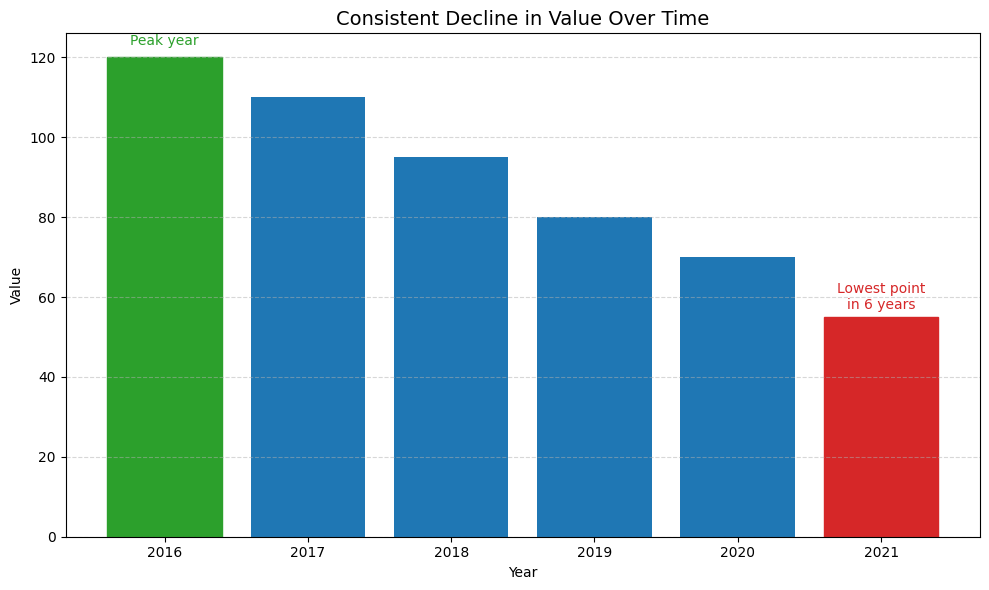

In [12]:
import matplotlib.pyplot as plt

# Sample data
years = ['2016', '2017', '2018', '2019', '2020', '2021']
values = [120, 110, 95, 80, 70, 55]

plt.figure(figsize=(10, 6))
bars = plt.bar(years, values, color='#1f77b4')

# Highlight key bars
bars[-1].set_color('#d62728')  # Emphasize 2021
bars[0].set_color('#2ca02c')   # Emphasize 2016

# Add annotation
plt.text('2021', 57, 'Lowest point\nin 6 years', ha='center', color='#d62728', fontsize=10)
plt.text('2016', 123, 'Peak year', ha='center', color='#2ca02c', fontsize=10)

# Title and axes
plt.title('Consistent Decline in Value Over Time', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Value')

# Remove frame and clutter
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 4. Storytelling With Data Plot

In this section, I reproduced a graph inspired by Chapter 7 of *Storytelling With Data* (pp. 165–185), which emphasizes clarity, simplicity, and narrative focus in visual communication. The plot I chose demonstrates a declining trend over time, with key data points highlighted through color and annotated callouts to guide the viewer’s attention.

The goal of this exercise is to move beyond technical visualization into the realm of persuasive, decision-support storytelling. This matters because data science is not only about extracting insights — it's about effectively communicating those insights to stakeholders who may not have technical backgrounds.

This section complements the earlier EDA by presenting a distilled, audience-focused message drawn from the deeper analysis. It represents how technical findings can be transformed into actionable visuals for business leaders, policy makers, or operational teams.